Anzal Azam Shaikh

DHC -1338

link to access: https://colab.research.google.com/drive/1rZmpUUPoCvO88f14or5r2bWttslsSX9D?usp=sharing

Task 3: Multimodal ML – Housing Price Prediction Using Images + Tabular
Data


Objective:

Predict housing prices using both structured data and house images.
Dataset:

Housing Sales Dataset + Custom Image Dataset (your own or any public source)
Instructions:

● Use CNNs to extract features from images

● Combine extracted image features with tabular data

● Train a model using both modalities

● Evaluate performance using MAE and RMSE

In [ ]:
!pip install tensorflow opencv-python

In [ ]:
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D

from tensorflow.keras.models import Model

In [ ]:
import os

print(os.listdir('/content'))

['.config', 'housing_data', 'House Rooms Image Dataset.zip', 'House Price Prediction Dataset.zip', 'sample_data']


In [ ]:
import zipfile

# Extract tabular dataset
with zipfile.ZipFile('/content/House Price Prediction Dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/housing_data')

# Extract image dataset
with zipfile.ZipFile('/content/House Rooms Image Dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/house_images')

print("✅ Extraction Done")

✅ Extraction Done


In [ ]:
os.listdir('/content/housing_data')

['House Price Prediction Dataset.csv']

In [ ]:
import os

for root, dirs, files in os.walk('/content'):
    for f in files:
        if f.endswith('.csv'):
            print("FOUND CSV:", os.path.join(root, f))

FOUND CSV: /content/housing_data/House Price Prediction Dataset.csv
FOUND CSV: /content/sample_data/california_housing_test.csv
FOUND CSV: /content/sample_data/mnist_test.csv
FOUND CSV: /content/sample_data/mnist_train_small.csv
FOUND CSV: /content/sample_data/california_housing_train.csv


In [ ]:
import pandas as pd

df = pd.read_csv('/content/housing_data/House Price Prediction Dataset.csv')

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [ ]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [ ]:
df = df.dropna()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,0,0,0,149919
1,2,4272,5,4,3,1958,0,0,0,424998
2,3,3592,2,2,3,1938,0,2,0,266746
3,4,966,4,2,2,1902,2,1,1,244020
4,5,4926,1,4,2,1975,0,1,1,636056


In [ ]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [ ]:
X_tabular = df.drop('Price', axis=1)
y = df['Price']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_tabular = scaler.fit_transform(X_tabular)

In [ ]:
os.listdir('/content/house_images')[:10]

['Task_1_End_to_End_ML_Pipeline_with_Scikit_learn_Pipeline_API.ipynb',
 'House_Room_Dataset']

In [ ]:
import os

image_folder = '/content/house_images/House_Room_Dataset'

print(os.listdir(image_folder)[:10])

['Kitchen', 'Livingroom', 'Dinning', 'Bedroom', 'Bathroom']


In [ ]:
import os

image_folder = '/content/house_images/House_Room_Dataset'

files = os.listdir(image_folder)
print(files[:20])
print("Total files:", len(files))

['Kitchen', 'Livingroom', 'Dinning', 'Bedroom', 'Bathroom']
Total files: 5


In [ ]:
from collections import Counter

exts = []

for f in os.listdir(image_folder):
    exts.append(f.split('.')[-1])

print(Counter(exts))

Counter({'Kitchen': 1, 'Livingroom': 1, 'Dinning': 1, 'Bedroom': 1, 'Bathroom': 1})


In [ ]:
import cv2
import numpy as np
import os

image_base = '/content/house_images/House_Room_Dataset'

images = []
labels = []

for folder in os.listdir(image_base):
    folder_path = os.path.join(image_base, folder)

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)

        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.resize(img, (128,128))
            img = img / 255.0
            images.append(img)
            labels.append(folder)

X_images = np.array(images)

print(X_images.shape)

(5250, 128, 128, 3)


In [ ]:
min_samples = min(len(X_images), len(X_tabular))

X_images = X_images[:min_samples]

X_tabular = X_tabular[:min_samples]

y = y[:min_samples]

In [ ]:
import os

print(os.listdir('/content/house_images')[:20])

['Task_1_End_to_End_ML_Pipeline_with_Scikit_learn_Pipeline_API.ipynb', 'House_Room_Dataset']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tab_train = scaler.fit_transform(X_tab_train)
X_tab_test = scaler.transform(X_tab_test)

In [ ]:
image_input = Input(shape=(128,128,3))

x = Conv2D(32, (3,3), activation='relu')(image_input)

x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu')(x)

x = MaxPooling2D((2,2))(x)

x = Flatten()(x)

x = Dense(128, activation='relu')(x)

In [ ]:
tabular_input = Input(shape=(X_tab_train.shape[1],))

y_tab = Dense(64, activation='relu')(tabular_input)

y_tab = Dense(32, activation='relu')(y_tab)

In [ ]:
combined = Concatenate()([x, y_tab])

z = Dense(64, activation='relu')(combined)

output = Dense(1)(z)

In [ ]:
model = Model(
    inputs=[image_input, tabular_input],
    outputs=output
)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 126, 126,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 63, 63,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 30, 30,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 57600)     │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │        640 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │  7,372,928 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      2,080 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 160)       │          0 │ dense_6[0][0],    │
│ (Concatenate)       │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │     10,304 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │         65 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,405,409 (28.25 MB)

 Trainable params: 7,405,409 (28.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split

X_img_train, X_img_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_images,
    X_tab_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_tab_train = scaler.fit_transform(X_tab_train)
X_tab_test = scaler.transform(X_tab_test)

In [ ]:
history = model.fit(
    [X_img_train, X_tab_train],
    y_train,
    validation_data=([X_img_test, X_tab_test], y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 334374141952.0000 - mae: 508255.0000 - val_loss: 207172976640.0000 - val_mae: 378138.7500
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 101198487552.0000 - mae: 266257.2500 - val_loss: 91018043392.0000 - val_mae: 255689.2031
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 82932146176.0000 - mae: 245269.2188 - val_loss: 93340213248.0000 - val_mae: 257290.8750
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 83125895168.0000 - mae: 245804.0781 - val_loss: 89703645184.0000 - val_mae: 254558.8438
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 82271846400.0000 - mae: 244721.8438 - val_loss: 89648627712.0000 - val_mae: 254190.2188
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 82753093632.0000 - mae: 245817.1719 - val_loss: 89968099328.0000 - val_mae: 254267.7812
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 81753726976.0000 - mae: 244036.1719 - val_loss: 90452312

In [ ]:
predictions = model.predict([X_img_test, X_tab_test])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 253489.328125
RMSE: 296562.2025275642


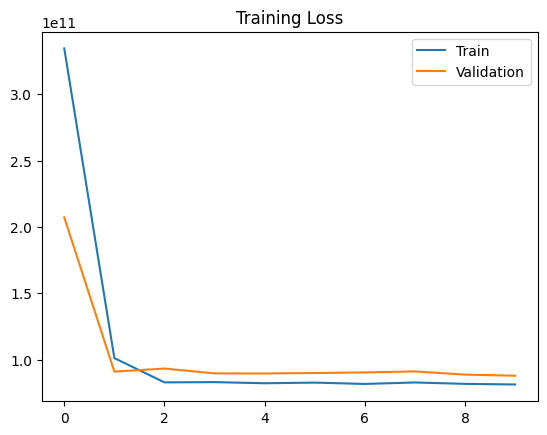

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training Loss')
plt.legend(['Train','Validation'])
plt.show()



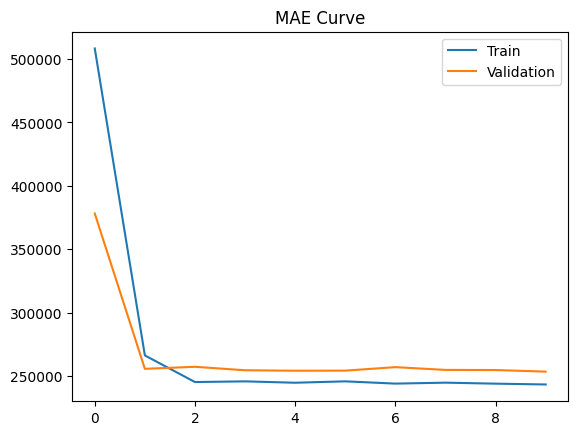

In [ ]:
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('MAE Curve')
plt.legend(['Train','Validation'])
plt.show()

In [ ]:
model.save("multimodal_model.h5")